In [ ]:
'''
Machine Learning
Dataset: Diabetes
Reason: Classic, lightweight dataset for classification, clustering, and visualization
Alternate url: http://archive.ics.uci.edu/ml/datasets/diabetes
Platform: Google Colab
Concepts covered:
Logistic Regression: a strong baseline for binary classification.
Decision Tree: easy to interpret and useful for non-linear splits.
Random Forest: usually stronger than a single tree because it averages many trees.
Gradient Boosting: often performs well on tabular data by building trees sequentially.
'''

In [1]:
# Install libraries and dependencies
!pip -q install ucimlrepo pyspark tensorflow scikit-learn seaborn matplotlib pandas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import beta

print("libraries ready")

libraries ready


In [2]:
# Set up Visualization grids
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)
print("Set up complete")

Set up complete


In [6]:
# Load dataset and print shape
import pandas as pd
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"

# Define column names
columns = [
    "pregnant",
    "glucose",
    "pressure",
    "thickness",
    "insulin",
    "mass",
    "pedigree",
    "age",
    "class"
]

df = pd.read_csv(url, names=columns)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

target_col = "class"

# Verify target values (should be 0 or 1)
print("\nTarget distribution:")
print(df[target_col].value_counts())

print("\nTarget unique values:")
print(df[target_col].unique())

Dataset shape: (768, 9)

First 5 rows:
   pregnant  glucose  pressure  thickness  insulin  mass  pedigree  age  class
0         6      148        72         35        0  33.6     0.627   50      1
1         1       85        66         29        0  26.6     0.351   31      0
2         8      183        64          0        0  23.3     0.672   32      1
3         1       89        66         23       94  28.1     0.167   21      0
4         0      137        40         35      168  43.1     2.288   33      1

Target distribution:
class
0    500
1    268
Name: count, dtype: int64

Target unique values:
[1 0]


In [7]:
# Basic statistical analysis
print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df[target_col].value_counts())



Summary statistics:
         pregnant     glucose    pressure   thickness     insulin        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.000000   99.000000  846.000000   67.100000   

         pedigree         age       class  
count  768.000000  768.000000  768.000000  
mean     0.471876   33.240885    0.348958  
std      0.331329   11.760232    0.476951  
min      0.078000   21.000000    0.000000  
25%      0.243750   24.000000

/tmp/ipykernel_14871/2397756562.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=df.columns[1], data=df, ax=axes[0, 1], palette="Set2")
/tmp/ipykernel_14871/2397756562.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, ax=axes[1, 1], palette="Set3")


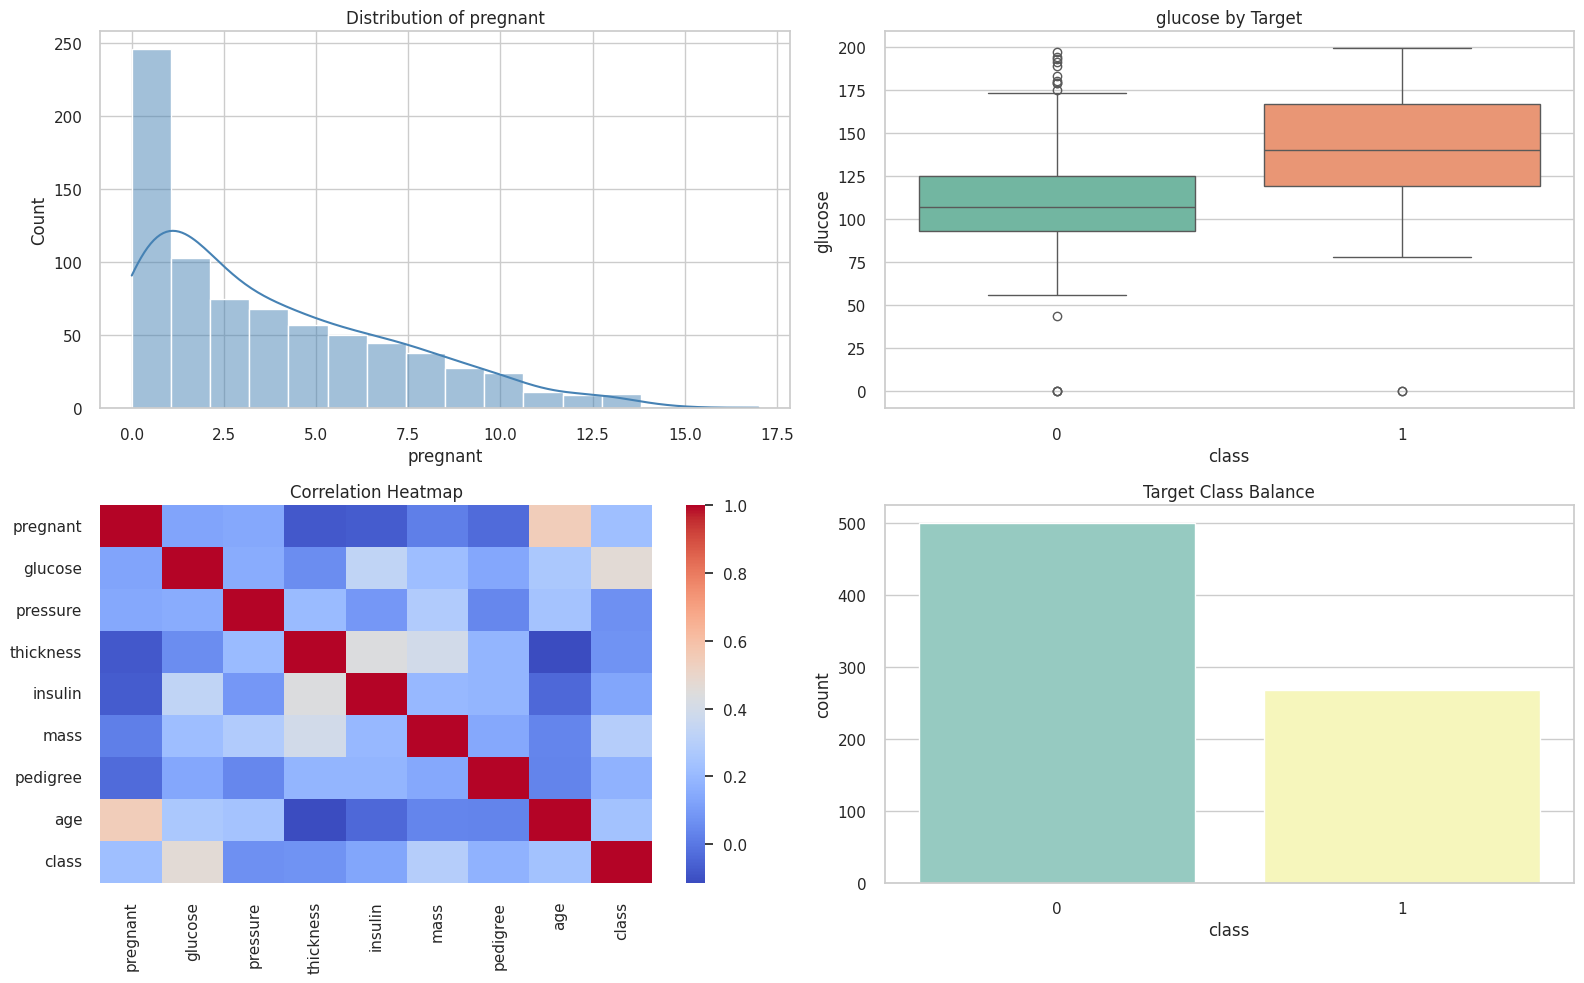

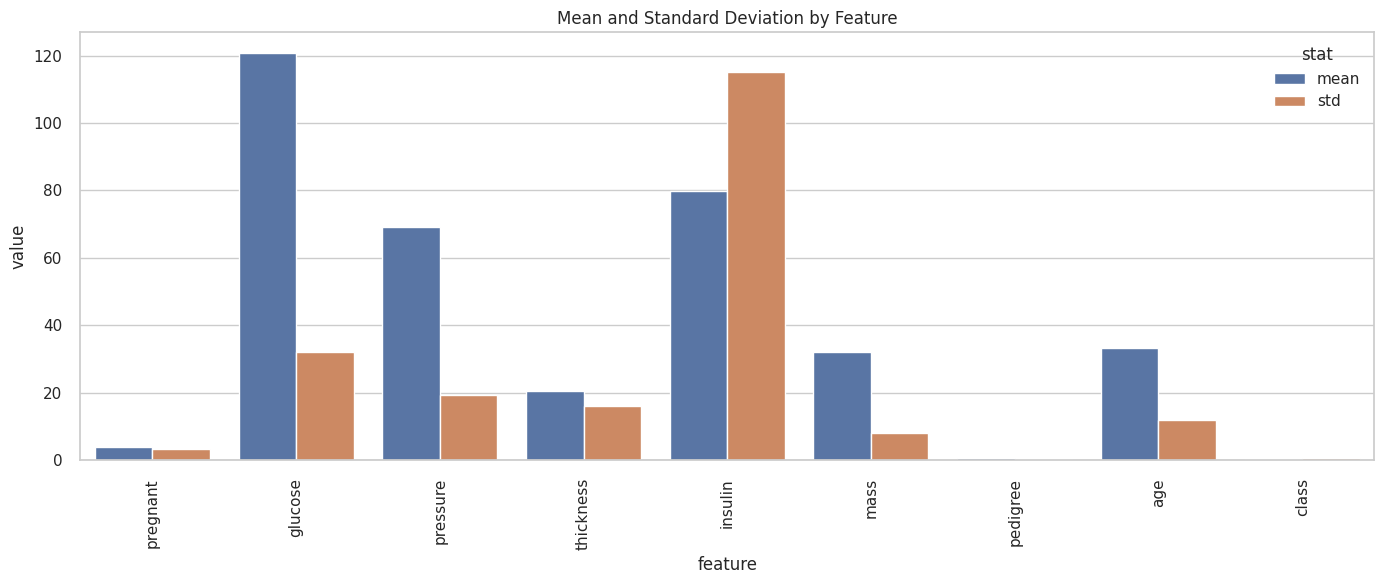

In [8]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df.iloc[:, 0], kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title(f"Distribution of {df.columns[0]}")

sns.boxplot(x=target_col, y=df.columns[1], data=df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title(f"{df.columns[1]} by Target")

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title("Correlation Heatmap")

sns.countplot(x=target_col, data=df, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Target Class Balance")

plt.tight_layout()
plt.show()

# Mean and standard deviation plot
summary = df.describe().T[["mean", "std"]].reset_index().rename(columns={"index": "feature"})
summary_long = summary.melt(id_vars="feature", value_vars=["mean", "std"], var_name="stat", value_name="value")

plt.figure(figsize=(14, 6))
sns.barplot(data=summary_long, x="feature", y="value", hue="stat")
plt.xticks(rotation=90)
plt.title("Mean and Standard Deviation by Feature")
plt.tight_layout()
plt.show()


In [9]:
# Prepare features
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

print("features ready")

features ready



Logistic Regression
Accuracy: 0.7142857142857143
ROC AUC: 0.8229629629629629
[[82 18]
 [26 28]]
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Decision Tree
Accuracy: 0.7922077922077922
ROC AUC: 0.7858333333333334
[[84 16]
 [16 38]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       100
           1       0.70      0.70      0.70        54

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154


Random Forest
Accuracy: 0.7467532467532467
ROC AUC: 0.8133333333333334
[[83 17]
 [22 32]]
              precision    recall  f1-score   support

           0

/tmp/ipykernel_14871/887945108.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="viridis")


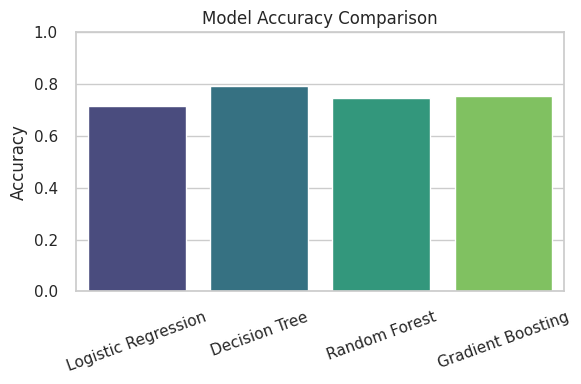

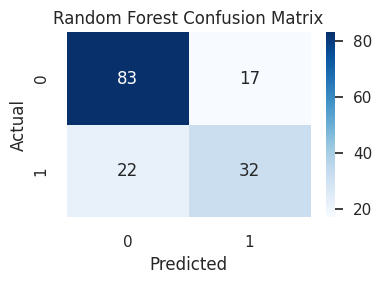

In [11]:
# Supervised Learning - Classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])
logit.fit(X_train, y_train)
pred_logit = logit.predict(X_test)
prob_logit = logit.predict_proba(X_test)[:, 1]

tree = DecisionTreeClassifier(random_state=42, max_depth=5)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
prob_tree = tree.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
prob_rf = rf.predict_proba(X_test)[:, 1]

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
prob_gb = gb.predict_proba(X_test)[:, 1]

def show_metrics(name, y_true, pred, prob):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("ROC AUC:", roc_auc_score(y_true, prob))
    print(confusion_matrix(y_true, pred))
    print(classification_report(y_true, pred))

show_metrics("Logistic Regression", y_test, pred_logit, prob_logit)
show_metrics("Decision Tree", y_test, pred_tree, prob_tree)
show_metrics("Random Forest", y_test, pred_rf, prob_rf)
show_metrics("Gradient Boosting", y_test, pred_gb, prob_gb)

accs = {
    "Logistic Regression": accuracy_score(y_test, pred_logit),
    "Decision Tree": accuracy_score(y_test, pred_tree),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "Gradient Boosting": accuracy_score(y_test, pred_gb),
}

plt.figure(figsize=(6, 4))
sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="viridis")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



Regression section (illustrative):
MSE: 9.520239170009562
Sample predictions: [5.19490745 2.22548882 1.9176107  3.75598798 6.59506912]


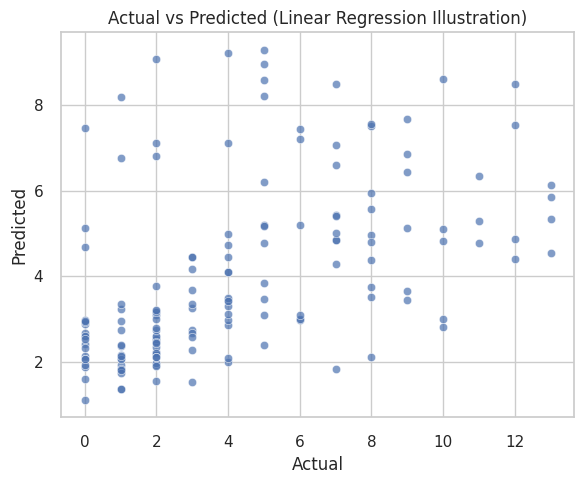

In [12]:
# Regression
# This dataset is a time-series/classification-type dataset in UCI, so regression here is illustrative.
y_reg = df[feature_cols[0]]
X_reg = df[feature_cols[1:]]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
reg.fit(X_train_r, y_train_r)
reg_pred = reg.predict(X_test_r)

print("\nRegression section (illustrative):")
print("MSE:", mean_squared_error(y_test_r, reg_pred))
print("Sample predictions:", reg_pred[:5])

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test_r, y=reg_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression Illustration)")
plt.tight_layout()
plt.show()



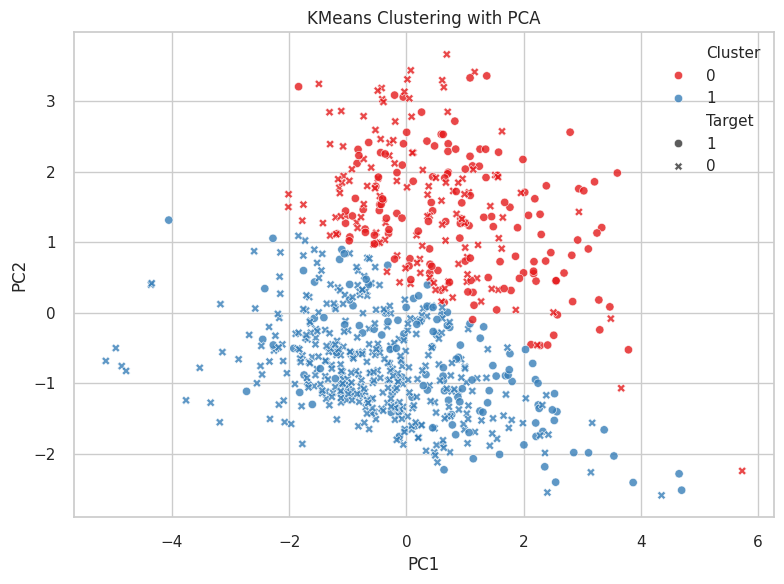

In [13]:
# Unsupervised Learning - Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters.astype(str),
    "Target": y.astype(str).values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="Cluster", style="Target", palette="Set1", alpha=0.8)
plt.title("KMeans Clustering with PCA")
plt.tight_layout()
plt.show()


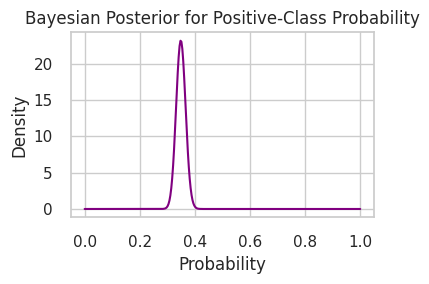


Posterior mean probability: 0.34935064935064936


In [15]:
# Bayesian modeling
successes = int(y.sum())
failures = int((1 - y).sum())
post_a = 1 + successes
post_b = 1 + failures

x_vals = np.linspace(0, 1, 300)
posterior = beta.pdf(x_vals, post_a, post_b)

plt.figure(figsize=(4, 3))
plt.plot(x_vals, posterior, color="purple")
plt.title("Bayesian Posterior for Positive-Class Probability")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print("\nPosterior mean probability:", post_a / (post_a + post_b))



TensorFlow test accuracy: 0.7597402334213257


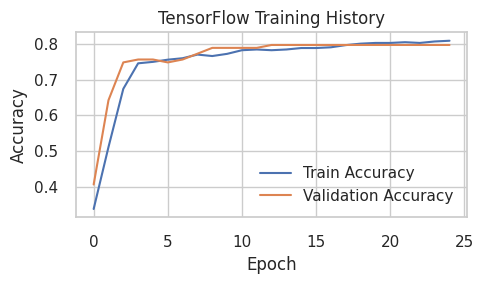

In [17]:
# TensorFlow model
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_scaled, y.values, test_size=0.2, random_state=42, stratify=y
)

tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

tf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = tf_model.fit(
    X_train_tf, y_train_tf,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    verbose=0
)

tf_loss, tf_acc = tf_model.evaluate(X_test_tf, y_test_tf, verbose=0)
print("\nTensorFlow test accuracy:", tf_acc)

plt.figure(figsize=(5, 3))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("TensorFlow Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
# PySpark
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkStandardScaler
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier as SparkDecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier as SparkRandomForestClassifier
from pyspark.ml.classification import GBTClassifier
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

spark = SparkSession.builder.master("local[*]").appName("DiabetesDataset").getOrCreate()
spark_df = spark.createDataFrame(df)

print("\nPySpark shape:", (spark_df.count(), len(spark_df.columns)))

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler_sp = SparkStandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

train_sp, test_sp = spark_df.randomSplit([0.8, 0.2], seed=42)

spark_lr = SparkLogisticRegression(featuresCol="features", labelCol=target_col, maxIter=50)
spark_dt = SparkDecisionTreeClassifier(featuresCol="features", labelCol=target_col)
spark_rf = SparkRandomForestClassifier(featuresCol="features", labelCol=target_col, numTrees=100)
spark_gbt = GBTClassifier(featuresCol="features", labelCol=target_col, maxIter=50)

pipeline_lr = SparkPipeline(stages=[assembler, scaler_sp, spark_lr])
pipeline_dt = SparkPipeline(stages=[assembler, scaler_sp, spark_dt])
pipeline_rf = SparkPipeline(stages=[assembler, scaler_sp, spark_rf])
pipeline_gbt = SparkPipeline(stages=[assembler, scaler_sp, spark_gbt])

m_lr = pipeline_lr.fit(train_sp)
m_dt = pipeline_dt.fit(train_sp)
m_rf = pipeline_rf.fit(train_sp)
m_gbt = pipeline_gbt.fit(train_sp)

p_lr = m_lr.transform(test_sp)
p_dt = m_dt.transform(test_sp)
p_rf = m_rf.transform(test_sp)
p_gbt = m_gbt.transform(test_sp)

evaluator = BinaryClassificationEvaluator(labelCol=target_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")

print("\nPySpark AUC scores:")
print("Logistic Regression:", evaluator.evaluate(p_lr))
print("Decision Tree:", evaluator.evaluate(p_dt))
print("Random Forest:", evaluator.evaluate(p_rf))
print("Gradient Boosting:", evaluator.evaluate(p_gbt))

spark.stop()



PySpark shape: (768, 9)

PySpark AUC scores:
Logistic Regression: 0.8523351648351648
Decision Tree: 0.820169413919414
Random Forest: 0.8697344322344323
Gradient Boosting: 0.7912087912087913


In [19]:
# End
print("\nCompleted diabetes dataset workflow.")



Completed diabetes dataset workflow.
